Many Machine Learning problems involve thousands or even millions of features for
each training instance. Not only does this make training extremely slow, it can also
make it much harder to find a good solution, as we will see. This problem is often
referred to as the curse of dimensionality.


Projection


In most real-world problems, training instances are not spread out uniformly across
all dimensions. Many features are almost constant, while others are highly correlated. As a result, all training instances actually lie within
(or close to) a much lower-dimensional subspace of the high-dimensional space.

Manifold learning

Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is by far the most popular dimensionality reduc‐
tion algorithm. First it identifies the hyperplane that lies closest to the data, and then
it projects the data onto it.

The following Python code uses NumPy’s svd() function to obtain all the principal
components of the training set, then extracts the first two PCs:

In [72]:
import numpy as np

X = np.c_[np.random.rand(100,1) , np.random.rand(100,1)]

X_centered = X - X.mean(axis = 0)
U, s, Vt = np.linalg.svd(X_centered)

c1 = Vt.T[:,0]
c2 = Vt.T[:,1]

In [73]:
X

array([[0.39381128, 0.46356394],
       [0.60440267, 0.40220544],
       [0.65327511, 0.22846048],
       [0.90083093, 0.18471116],
       [0.09161545, 0.31496154],
       [0.64836152, 0.45158269],
       [0.76053778, 0.05029784],
       [0.18132019, 0.98241313],
       [0.70532883, 0.01659078],
       [0.23920065, 0.49800674],
       [0.67769836, 0.44881917],
       [0.19058359, 0.14685556],
       [0.27109982, 0.00471006],
       [0.10271025, 0.13159949],
       [0.9441147 , 0.45464538],
       [0.14307416, 0.43166463],
       [0.42380372, 0.91928702],
       [0.27505262, 0.98688935],
       [0.46360596, 0.68020248],
       [0.31003567, 0.13415289],
       [0.78756317, 0.61513374],
       [0.91194239, 0.72872564],
       [0.11227388, 0.14938165],
       [0.21255382, 0.13994275],
       [0.57088134, 0.76870535],
       [0.16203354, 0.29159559],
       [0.46209641, 0.01895665],
       [0.31991874, 0.70113984],
       [0.57067769, 0.03123106],
       [0.28544216, 0.19547895],
       [0.

In [74]:
Vt

array([[ 0.09781033,  0.99520507],
       [-0.99520507,  0.09781033]])

In [75]:
c2

array([-0.99520507,  0.09781033])

In [76]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca.fit_transform(X)

array([[ 5.01583506e-04, -6.37678400e-02],
       [-3.99646879e-02,  1.51815282e-01],
       [-2.08096332e-01,  2.17447434e-01],
       [-2.27422355e-01,  4.68095372e-01],
       [-1.76946152e-01, -3.49979808e-01],
       [ 1.34754269e-02,  1.90733749e-01],
       [-3.74913294e-01,  3.41621935e-01],
       [ 4.96079110e-01, -3.25988852e-01],
       [-4.13858741e-01,  2.89974598e-01],
       [ 1.96567196e-02, -2.21005978e-01],
       [ 1.35945993e-02,  2.20200219e-01],
       [-3.34565965e-01, -2.35043714e-01],
       [-4.68154569e-01, -1.41010259e-01],
       [-3.58343809e-01, -3.21003509e-01],
       [ 4.54511510e-02,  4.84769250e-01],
       [-5.57694540e-02, -3.10182608e-01],
       [ 4.56973082e-01, -7.84936274e-02],
       [ 5.09701864e-01, -2.33143682e-01],
       [ 2.22928004e-01, -1.54972991e-02],
       [-3.35524079e-01, -1.14921941e-01],
       [ 1.89857617e-01,  3.13270950e-01],
       [ 3.15070429e-01,  4.25943326e-01],
       [-3.39711490e-01, -3.13225016e-01],
       [-3.

In [77]:
pca.explained_variance_ratio_

array([0.56372483, 0.43627517])

In [78]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784',version=1)
X = mnist["data"]
y= mnist['target']

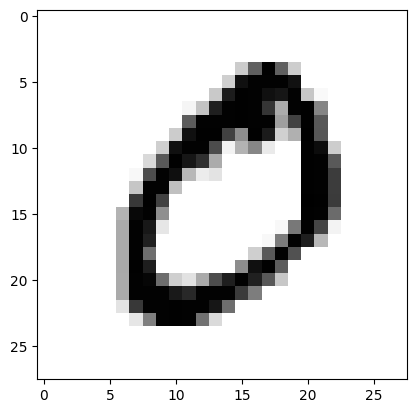

In [79]:
digit_1 = X.iloc[1].values
digit_1_reshaped = digit_1.reshape(28,28)

import matplotlib.pyplot as plt
plt.imshow(digit_1_reshaped, cmap ="binary")

In [82]:
pca = PCA(n_components = 154)
X_converted = pca.fit_transform(X)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

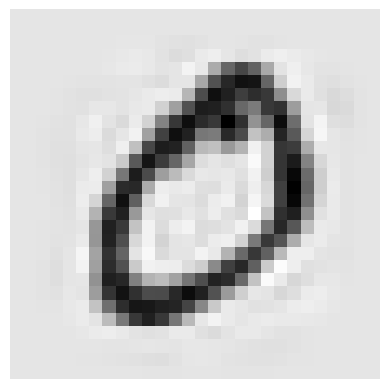

In [83]:
X_recovered = pca.inverse_transform(X_converted )
digit_1 = X_recovered[1]
digit_1_reshaped = digit_1.reshape(28,28)
plt.imshow(digit_1_reshaped,cmap='binary')
plt.axis("off")

The mean squared distance between the original data and the reconstructed data
(compressed and then decompressed) is called the reconstruction error.

In [84]:
from sklearn.datasets import make_swiss_roll
X,t = make_swiss_roll(n_samples = 1000, noise =0.2, random_state = 42)
print(X.shape)

(1000, 3)


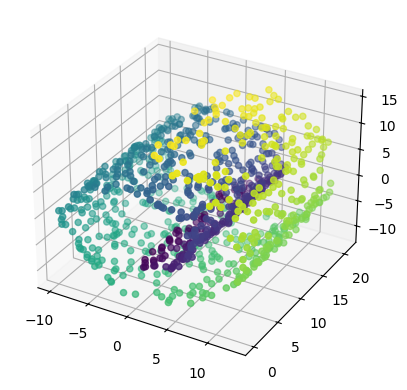

In [85]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

ax.scatter(X[:,0],X[:,1],X[:,2],c=t)
plt.show()

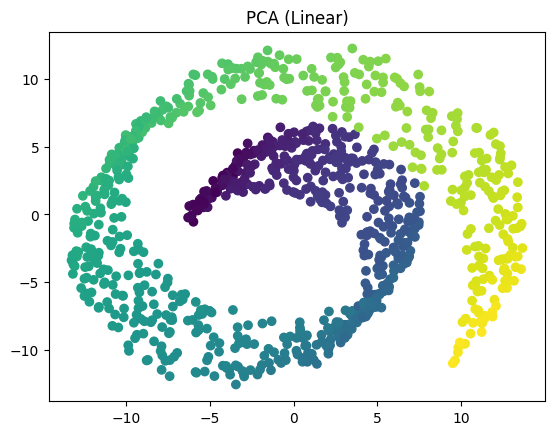

In [86]:
from sklearn.decomposition import PCA
pca=PCA(n_components = 2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0],X_pca[:,1],c=t)
plt.title("PCA (Linear)")
plt.show()

(array([114., 112.,  95., 102.,  81., 111.,  98.,  88., 100.,  99.]),
 array([ 4.75604477,  5.6938909 ,  6.63173703,  7.56958316,  8.50742929,
         9.44527542, 10.38312155, 11.32096768, 12.25881381, 13.19665994,
        14.13450607]),
 <BarContainer object of 10 artists>)

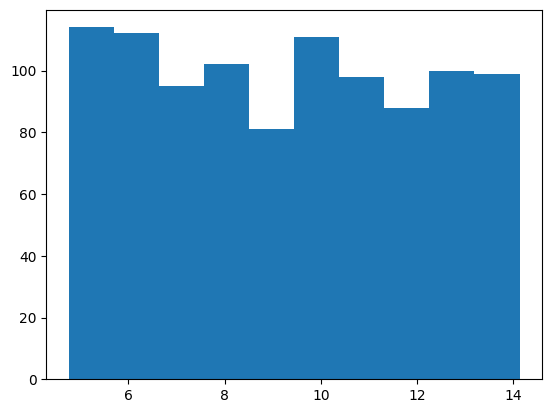

In [95]:
plt.hist(t)

In [96]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components = 2, kernel="rbf",gamma=0.04)
X_kpca = rbf_pca.fit_transform(X)

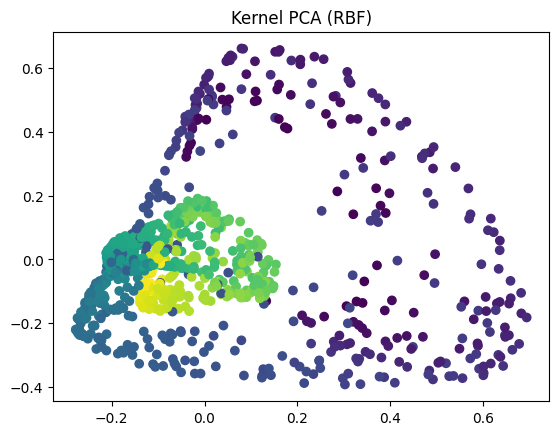

In [97]:
plt.scatter(X_kpca[:,0], X_kpca[:,1], c=t)
plt.title("Kernel PCA (RBF)")
plt.show()

Selecting a Kernel and Tuning Hyperparameters using GridSearch

In [106]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target